<a href="https://colab.research.google.com/github/jaearao/App-155/blob/Assignments/ARAO_lab_assignment_module5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AP155 Lab Assignment**
## Module 5: Partial Differential Equations

_Instructions_: Answer each problem as completely as you can. Discuss **all** your answers as clearly and concisely as possible.

_Scoring Criteria_: 50% - *correctness of code*; 50% - *discussion of the code and results*. Maximum score is **100 points**.



### Student Information

_Full Name (Last Name, First Name)_: Arao, John Robert \
_Student No._: 2022-01967 \
_Section_: TX3

### Submission Information

_Date and Time Submitted (most recent upload)_: November 16,2024 6:20pm

**HONOR PLEDGE** I affirm that I have upheld the highest principles of honesty and integrity in my academic work and that this lab assignment is my own work.

**Sign here with your full name: John Robert Arao**

### Grading Information (c/o Lab Instructor)

TOTAL SCORE: **[]**/100

Score breakdown:
* Problem 1 - []/100

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_

### PROBLEM 1
**The Schrodinger equation and the Crank-Nicolson method**

_Refer to Exercise 9.8 in the Newman text._ In this problem, you will use the Crank-Nicolson method to solve the full time-dependent Schrodinger equation and hence develop a picture of how a wavefunction evolves over time.

Consider an electron (mass $M = 9.109 \times 10^{-31}$ kg) in a box of length $L = 10^{-8}$ m. Suppose that at time $t = 0$ the wavefunction of the electron has the form

$$ \psi(x,0) = \exp\left[-\frac{(x-x_0)^2}{2\sigma^2}\right]e^{i\kappa x},$$
where $x_0 = \frac{L}{2}$, $\sigma = 1 \times 10^{-10}$ m, $\kappa = 5 \times 10^{10} {\rm m}^{-1}$,  and $\psi = 0$ on the walls at $x = 0$ and $x = L$.

1. Perform a single step of the Crank-Nicolson method for this electron, calculating the vector $\psi(t)$ of values of the wavefunction, given the initial wavefunction above and using $N = 1000$ spatial slices with $a = L/N$. Your program will have to perform the following steps. First, given the vector $\psi(0)$ at $t = 0$, you will have to multiply by the matrix $\bf{B}$ to get a vector $\bf{v} = \bf{B}\psi$. Because of the tridiagonal form of $\bf{B}$, this is fairly simple. The $i$th component of $\bf{v}$ is given by
$$ v_i = b_1\psi_i + b_2(\psi_{i+1} + \psi_{i-1}).$$

   You will also have to choose a value for the time-step $h$. A reasonable choice is $h = 10^{-18}$ s. *(30 pts.)*

2. Second you will have to solve the linear system ${\bf Ax}= {\bf v}$ for $\bf{x}$, which gives you the new value of $\psi$. You could do this using a standard linear equation solver like the function $\tt solve$ in numpy's $\tt linalg$. *(20 pts.)*

3. Once you have the code in place to perform a single step of the calculation, extend your program to perform repeated steps and hence solve for $\psi$ at a sequence of times a separation $h$ apart. Note that the matrix $\bf A$ is independent of time, so it doesn't change from one step to another. You can set up the matrix just once and then keep on reusing it for every step. *(30 pts.)*

4. Make an animation of the solution by displaying the real part of the wavefunction at each time-step. You can use the function rate from the package visual to ensure a smooth frame-rate for your animation-- see Section 3.5 on page 117 of the Newman text.

   Run your animation for a while and describe what you see. Write a few sentences explaining in physics terms what is going on in the system. *(20 pts.)*

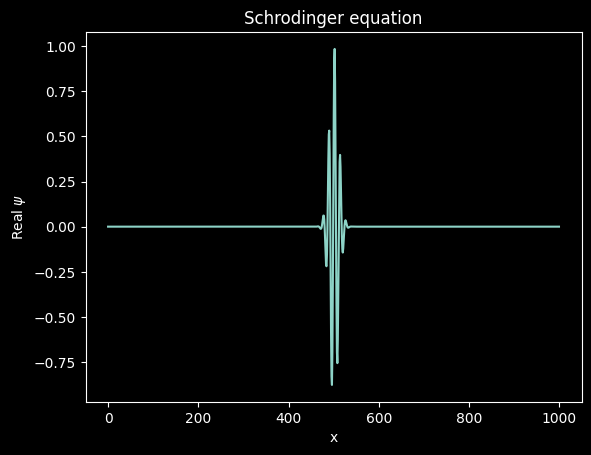

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

#define the constants and given
M = 9.109e-31
L = 10**(-8)
kappa = 5e10
sigma = 1e-10
x0 = L/2

#given in step 1
h = 1e-18
N = 1000
a = L/N
hbar = 1.054571817*10**-34

#define psi
x = np.arange(0, L, a)
psi = np.zeros(N, dtype=complex)
for i in range(N):
    psi[0] = psi[-1] = 0
    psi[i] = np.exp(-((x[i]-x0)**2)/(2*sigma**2))*np.exp(1j*kappa*x[i])

#define the components of martrix A
a1 = 1 + h*1.0j*hbar/(4*M*a**2)
a2 = -h*1.0j*hbar/(4*M*a**2)
A = np.diag([a1]*(N), 0) + np.diag([a2]*(N-1), 1) + np.diag([a2]*(N-1), -1)

#define the components of matrix B
b1 = 1 - h*1.0j*hbar/(4*M*a**2)
b2 = h*1.0j*hbar/(4*M*a**2)
B = np.diag([b1]*(N), 0) + np.diag([b2]*(N-1), 1) + np.diag([b2]*(N-1), -1)


#solve for vector v
def v(psi) :
  v = np.zeros(N, dtype=complex)
  for i in range(N-1):
    psi[0] = psi[-1] = 0
    v[i] = b1*psi[i] + b2*(psi[i+1] + psi[i-1])

  psi = np.linalg.solve(A, v)
  return psi

#show the first iteration
plt.style.use('dark_background')
psi0 = v(psi)
plt.plot(np.real(psi0))
plt.xlabel('x')
plt.ylabel('Real $\psi$')
plt.title('Schrodinger equation')
plt.show()

##First Iteration

The instructions pretty much covered how the Schodinger Equation can be solved and modeled in python. The only thing left is to visually cross check the solution with the expected behavior of the solution.

From the first iteration,it is evident in the figure above that it follows a wave form as expected from the solution of $\psi (x,0)$. The position of the wave is concentrated in the middle. This is expected as the $x_0 = \frac{L}{2}$.

One should note that only the real part of $\psi$ is represented as it is the only observable part of psi.

In [9]:
fig, ax = plt.subplots()
line, = ax.plot(x, np.real(psi))
ax.set_xlabel('x')
ax.set_ylabel('Real(ψ)')
ax.set_ylim([-1, 1])
ax.set_title('Schrodinger equation')

def animate(i):
    global psi
    psi = v(psi)
    line.set_ydata(np.real(psi))
    return line,

anim = animation.FuncAnimation(fig, animate, frames=2000, interval=25, blit=True)
plt.close()
HTML(anim.to_html5_video())

## Animation of 2000 iterations

As expected, the wave propagates from left to right. As it hits the wall, it follows the classical behavior of reflecting back. Hence, it propagates back to the other wall while maintaining its behavior as a wave.

The schrodinger equation is a partial differential equation that follows certain boundary conditions to solve the solution. In this problem, it is restricted in a box with a possible infinite potention on its walls. Hence, the wave just reflects back and forth within the box.

> The **Crank-Nicolson method** successfully solves the schrodinger equation as represented by the animation.  
